<a href="https://colab.research.google.com/github/grumpyoldking/COMP3710/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
train: 9664 | val: 1120 | batch=32


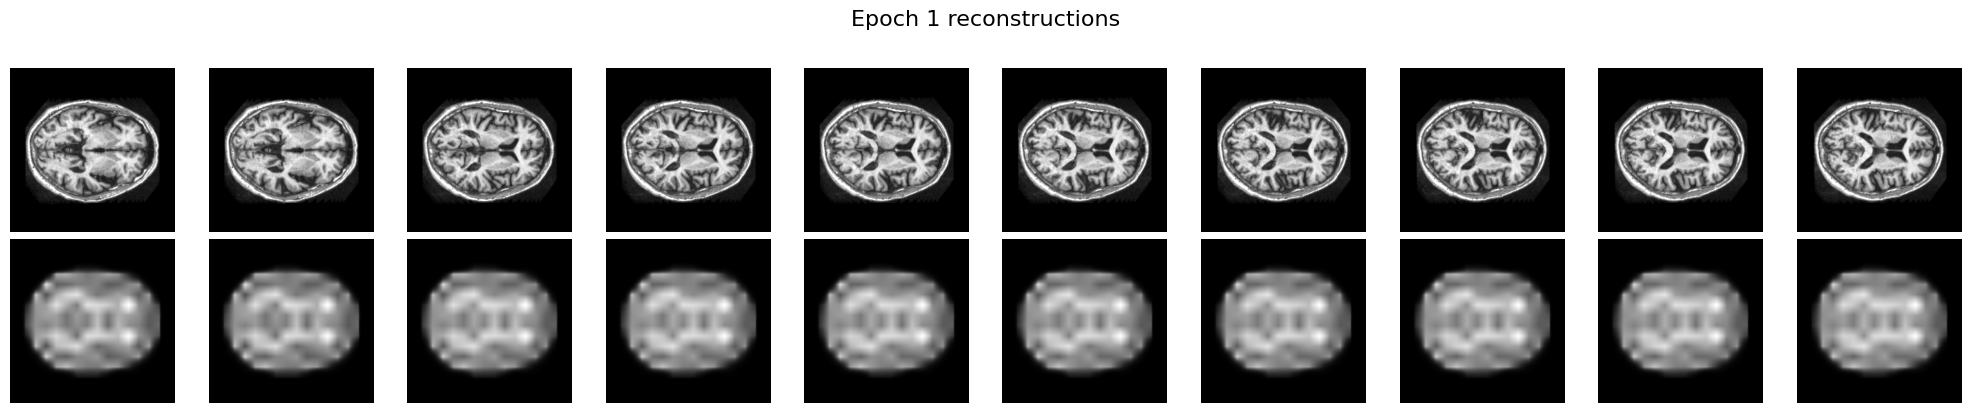

Epoch 01 | train=22929.5350 (bce=22858.7952, kld=70.7398) | val=18913.5468 | 140.3s


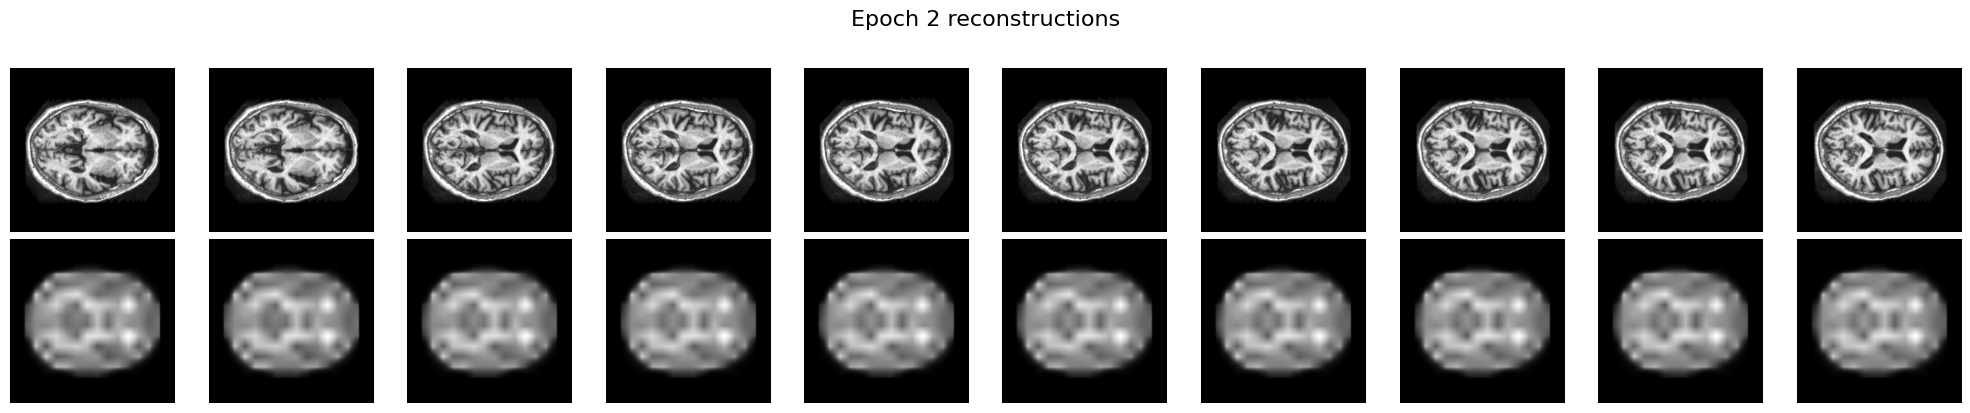

Epoch 02 | train=18926.7220 (bce=18875.7579, kld=50.9641) | val=18807.3916 | 46.0s


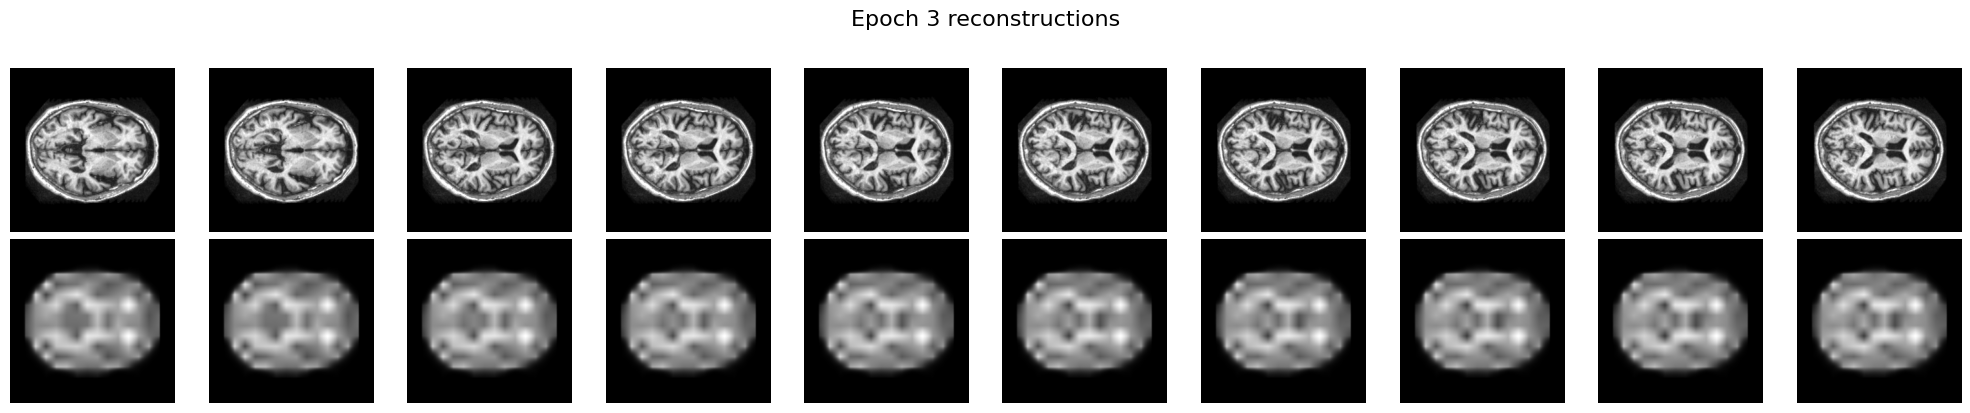

Epoch 03 | train=18835.9697 (bce=18786.9799, kld=48.9897) | val=18720.5583 | 47.0s


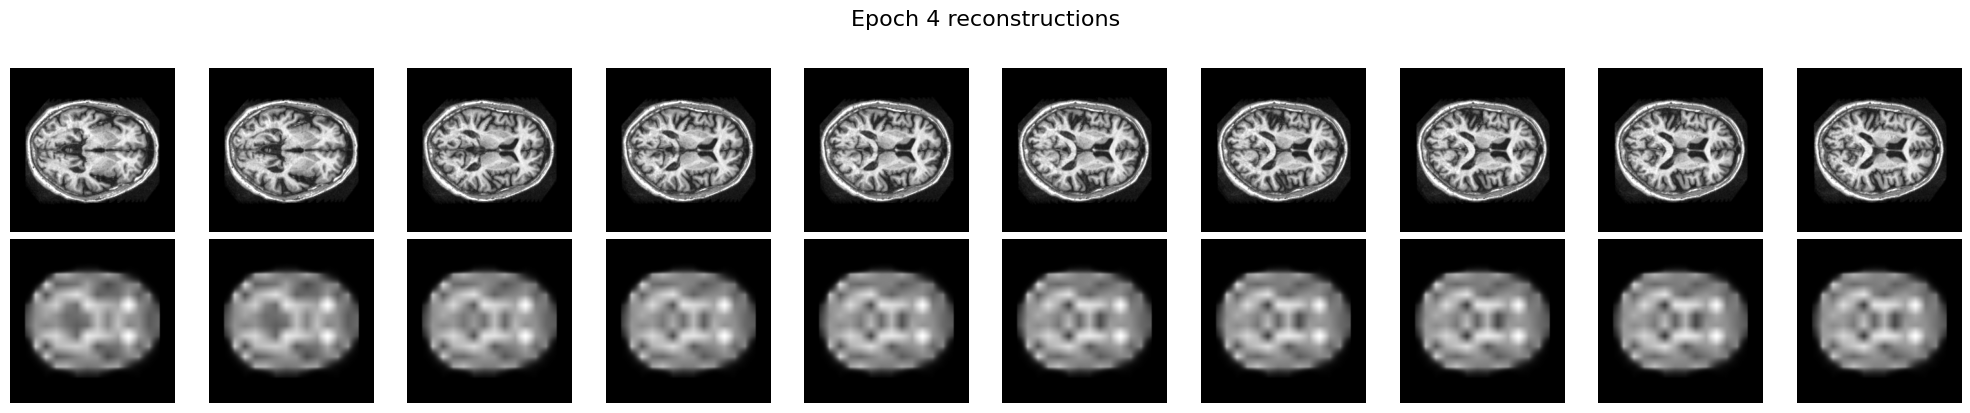

Epoch 04 | train=18783.0771 (bce=18734.1970, kld=48.8802) | val=18689.6890 | 47.3s


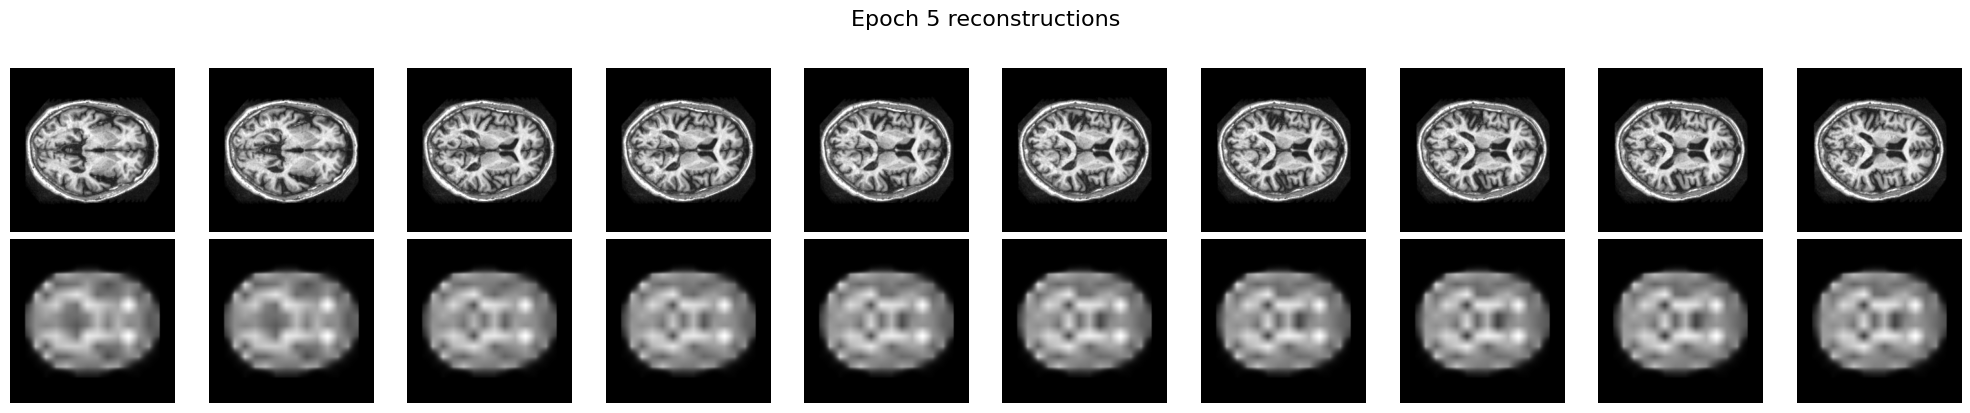

Epoch 05 | train=18734.0834 (bce=18685.4467, kld=48.6367) | val=18685.2704 | 47.1s


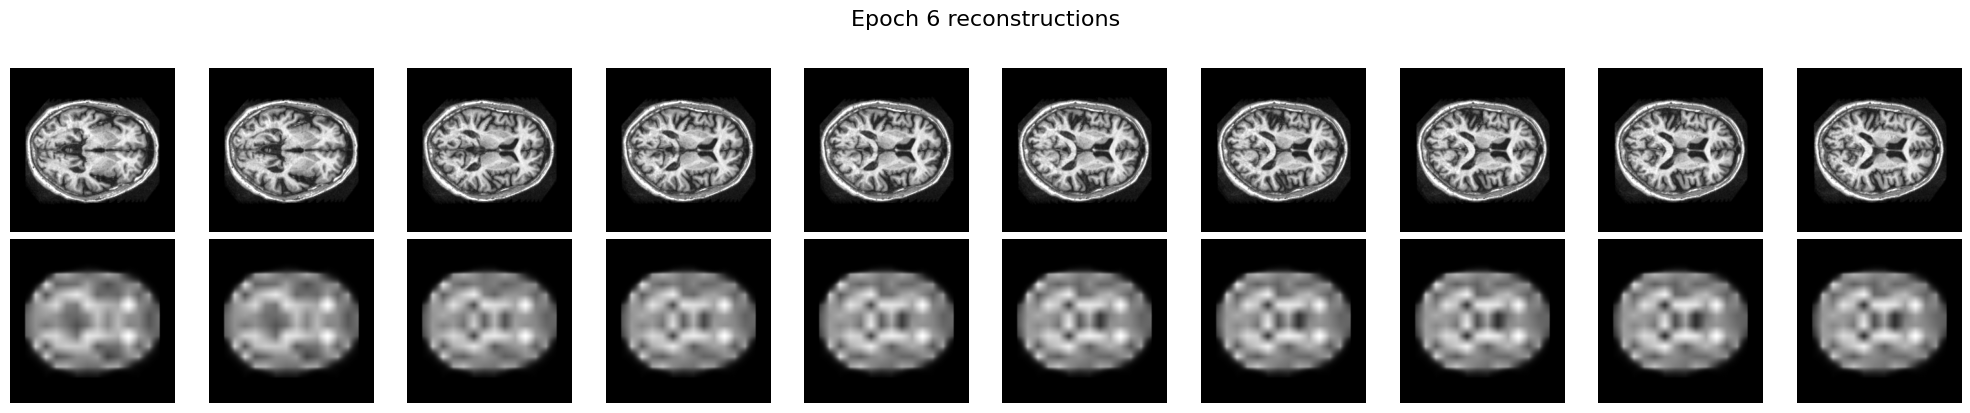

Epoch 06 | train=18695.1193 (bce=18645.9415, kld=49.1778) | val=18644.3059 | 46.2s


In [16]:
# =========================== CONFIG ===========================
BASE = "/content/drive/MyDrive/keras_png_slices_data/keras_png_slices_data"

TRAIN_DIR = f"{BASE}/keras_png_slices_train"
VAL_DIR   = f"{BASE}/keras_png_slices_validate"

IMG_SIZE    = 256         # <-- 256x256 PNGs
LATENT_DIM  = 32
BATCH_SIZE  = 32          # 256x256 uses more VRAM; lower batch size is safer
EPOCHS      = 6
WORKERS     = 1           # Colab usually prefers 1
LR          = 1e-3
USE_AMP     = True
SEED        = 42
PLOT_EVERY  = 1
TRAIN_LIMIT = None
VAL_LIMIT   = None

# ========================= IMPORTS ============================
import os, glob, random, time
from typing import List, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# ========================= UTILITIES ==========================
def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    if device.type == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

def _find_files(root: str, exts=(".png",".jpg",".jpeg")) -> List[str]:
    paths=[]
    for e in exts: paths += glob.glob(os.path.join(root,"**",f"*{e}"), recursive=True)
    paths.sort(); return paths

def _percentile_minmax(x: np.ndarray, lo=1, hi=99):
    x = x.astype(np.float32)
    a, b = np.percentile(x, lo), np.percentile(x, hi)
    if b <= a: b = a+1.0
    x = (x - a) / (b - a)
    return np.clip(x, 0.0, 1.0)

# ========================= DATASET ============================
class PNGSlices256(Dataset):
    """Load grayscale PNG/JPEG slices, robust-normalize, resize to 256x256 -> [1,256,256] in [0,1]."""
    def __init__(self, root: str, limit: Optional[int] = None):
        files = _find_files(root)
        if limit: files = files[:limit]
        if not files: raise RuntimeError(f"No images under {root}")
        self.files = files

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        p = self.files[idx]
        try:
            img_pil = Image.open(p).convert("L")
        except Exception:
            return self.__getitem__((idx + 1) % len(self))
        arr = np.array(img_pil)
        arr = _percentile_minmax(arr)
        img = Image.fromarray((arr*255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
        x = torch.tensor(np.asarray(img), dtype=torch.float32).unsqueeze(0) / 255.0  # [1,256,256]
        return x, p

# ========================= YOUR VAE (adapted for 256 by GAP) ===========================
class CNNVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: same conv blocks but finish with AdaptiveAvgPool2d((4,4))
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout2d(0.2),
            nn.MaxPool2d(2),  # 256 -> 128

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout2d(0.2),
            nn.MaxPool2d(2),  # 128 -> 64

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.Dropout2d(0.2),
            nn.MaxPool2d(2, 2, 1),  # 64 -> 32 (with padding)

            # NEW: make feature map size fixed to 4x4 regardless of input size
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
        )

        self.fc_mu     = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder: same blocks; final Upsample goes to 256x256 now
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 4 -> 8
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout2d(0.2),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout2d(0.2),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),  # 16 -> 16
            nn.Upsample(size=(256, 256), mode='bilinear', align_corners=False),  # <-- 256x256 output
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# Loss (unchanged)
def vae_loss_function(recon_x, x, mu, logvar, beta=1.0):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

def show_recons(x, recon, title="Reconstructions", cols=10):
    if x.size(0) < cols:  # pad if small batch
        reps = (cols + x.size(0) - 1)//x.size(0)
        x = x.repeat(reps,1,1,1); recon = recon.repeat(reps,1,1,1)
    x_np = x[:cols].detach().cpu().numpy()
    r_np = recon[:cols].detach().cpu().numpy()
    fig, axs = plt.subplots(2, cols, figsize=(2*cols, 4))
    for k in range(cols):
        axs[0,k].imshow(x_np[k,0], cmap='gray'); axs[0,k].axis('off')
        axs[1,k].imshow(r_np[k,0], cmap='gray'); axs[1,k].axis('off')
    fig.suptitle(title, fontsize=16, y=1.02); plt.tight_layout(); plt.show()

# ========================= BUILD LOADERS ======================
seed_all(SEED)
train_ds = PNGSlices256(TRAIN_DIR, limit=TRAIN_LIMIT)
val_ds   = PNGSlices256(VAL_DIR,   limit=VAL_LIMIT)

pin = (device.type == 'cuda')
common = dict(batch_size=BATCH_SIZE, num_workers=WORKERS, pin_memory=pin, persistent_workers=False)
if WORKERS > 0:
    common["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, shuffle=True,  drop_last=False, **common)
val_loader   = DataLoader(val_ds,   shuffle=False, drop_last=False, **common)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | batch={BATCH_SIZE}")

# ========================= MODEL + AMP ========================
vae = CNNVAE(latent_dim=LATENT_DIM).to(device)
if device.type == 'cuda':
    vae = vae.to(memory_format=torch.channels_last)

optimizer = torch.optim.Adam(vae.parameters(), lr=LR)
scaler = GradScaler(enabled=(USE_AMP and device.type=='cuda'))

# ========================= TRAINING LOOP ======================
for epoch in range(1, EPOCHS+1):
    vae.train()
    tot = tbce = tkld = 0.0
    t0 = time.time()
    for x, _ in train_loader:
        if device.type == 'cuda':
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward in AMP (fast)
        with autocast(device_type='cuda', dtype=torch.float16, enabled=(USE_AMP and device.type=='cuda')):
            recon, mu, logvar = vae(x)

        # Loss in FP32 (AMP-safe for Sigmoid+BCE)
        with torch.amp.autocast('cuda', enabled=False):
            loss, bce, kld = vae_loss_function(recon.float(), x.float(), mu.float(), logvar.float(), beta=1.0)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        tot += loss.item(); tbce += bce.item(); tkld += kld.item()

    tr_loss = tot/len(train_loader.dataset)
    tr_bce  = tbce/len(train_loader.dataset)
    tr_kld  = tkld/len(train_loader.dataset)

    # ---- Validation ----
    vae.eval(); vtot = 0.0
    with torch.no_grad():
        for xv,_ in val_loader:
            if device.type == 'cuda':
                xv = xv.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                xv = xv.to(device, non_blocking=True)

            with autocast(device_type='cuda', dtype=torch.float16, enabled=(USE_AMP and device.type=='cuda')):
                recon_v, mu_v, logvar_v = vae(xv)
            with torch.amp.autocast('cuda', enabled=False):
                v, _, _ = vae_loss_function(recon_v.float(), xv.float(), mu_v.float(), logvar_v.float(), beta=1.0)
            vtot += v.item()
        if (epoch % PLOT_EVERY == 0) or (epoch == EPOCHS):
            show_recons(xv, recon_v, title=f"Epoch {epoch} reconstructions")

    val_loss = vtot/len(val_loader.dataset)
    print(f"Epoch {epoch:02d} | train={tr_loss:.4f} (bce={tr_bce:.4f}, kld={tr_kld:.4f}) "
          f"| val={val_loss:.4f} | {time.time()-t0:.1f}s")


Using latent dims: 0 and 1


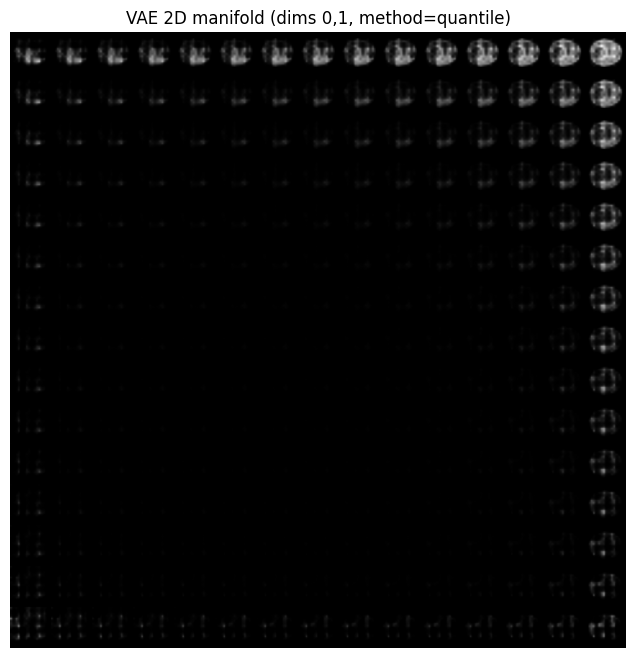

In [17]:
import math, numpy as np, torch
import matplotlib.pyplot as plt

@torch.no_grad()
def make_manifold_grid(
    vae,
    n=15,                     # grid size (n x n)
    dims=None,                # None -> pick 2 dims automatically; or pass tuple like (0,1)
    method="quantile",        # "quantile" (recommended) or "linspace"
    lim=3.0,                  # range for "linspace" mode
    batch=64,                 # decode batch size
    device=device,
):
    """
    Build a 2D manifold image by sampling a grid in the latent space and decoding.
    - If LATENT_DIM == 2: grid spans both latents.
    - Else: uses two chosen dims; others fixed to 0.
    - method="quantile": map evenly-spaced probs to N(0,1) via inverse CDF (better for Gaussian prior).
      method="linspace": equally spaced in [-lim, lim].
    """
    vae.eval()

    D = LATENT_DIM
    # choose which two latent dims to visualize
    if D == 2:
        dim1, dim2 = 0, 1
    else:
        if dims is None:
            # pick two distinct dims with most variance-ish: use the first two by default
            dim1, dim2 = 0, 1
        else:
            dim1, dim2 = dims
    print(f"Using latent dims: {dim1} and {dim2}")

    # sample coordinates along each axis
    if method == "quantile":
        # evenly spaced probabilities -> transform via Normal inverse CDF
        q = torch.linspace(0.01, 0.99, n, device=device)
        # Normal(0,1) inverse CDF via erfinv: Phi^{-1}(q) = sqrt(2) * erfinv(2q-1)
        axis = math.sqrt(2) * torch.erfinv(2*q - 1)
    elif method == "linspace":
        axis = torch.linspace(-lim, lim, n, device=device)
    else:
        raise ValueError("method must be 'quantile' or 'linspace'")

    # meshgrid of 2D points
    X, Y = torch.meshgrid(axis, axis, indexing="ij")  # shape [n, n]

    # build all latent points
    Z = torch.zeros(n*n, D, device=device, dtype=torch.float32)
    Z[:, dim1] = X.reshape(-1)
    Z[:, dim2] = Y.reshape(-1)

    # decode in mini-batches to avoid OOM
    imgs = []
    for i in range(0, Z.size(0), batch):
        zchunk = Z[i:i+batch]
        out = vae.decode(zchunk)           # decoder already has Sigmoid -> [0,1]
        out = out.clamp(0,1).detach().cpu()  # [B,1,H,W]
        imgs.append(out)
    imgs = torch.cat(imgs, dim=0)            # [n*n,1,H,W]

    # tile into a single big image
    H, W = IMG_SIZE, IMG_SIZE
    canvas = torch.zeros(1, n*H, n*W)
    k = 0
    for i in range(n):
        for j in range(n):
            canvas[0, i*H:(i+1)*H, j*W:(j+1)*W] = imgs[k,0]
            k += 1

    # plot
    plt.figure(figsize=(8,8))
    plt.imshow(canvas[0].numpy(), cmap="gray")
    plt.axis("off")
    plt.title(f"VAE 2D manifold (dims {dim1},{dim2}, method={method})")
    plt.show()

# === run it ===
# Tip: start with n=15; raise to 20 if you have time/GPU headroom
make_manifold_grid(vae, n=15, dims=(0,1), method="quantile")
